<a href="https://colab.research.google.com/github/nrozylo/projekt_2026/blob/main/projekt_energy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Energy Consumption - visualization, Linear Regression**

**Cel projektu:** zbudowanie modelu machine-learning przewidującego zużycie energii w danym budynku. Przewidywanie będzie bazowało na takich danych jak metraż, liczba używanych urządzeń, czy liczba osób w budynku.

**Kroki podjęte w projekcie:**
1. Import bibliotek oraz datasetu
2. Wizualizacja danych
3. Czyszczenie danych, przygotowanie do trenowania
4. Zbudowanie modeli Linear Regression oraz Random Forest Regressor, użycie GridSearch, porównanie modeli.

# **1. Import bibliotek oraz datasetu**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [ ]:
!wget https://raw.githubusercontent.com/nrozylo/projekt_2026/refs/heads/main/train_energy_data.csv
energy = pd.read_csv("train_energy_data.csv")
display(energy.head())

--2026-06-10 17:37:29--  https://raw.githubusercontent.com/nrozylo/projekt_2026/refs/heads/main/train_energy_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 44806 (44K) [text/plain]
Saving to: ‘train_energy_data.csv.3’

train_energy_data.c 100%[===================>]  43.76K  --.-KB/s    in 0.01s   

2026-06-10 17:37:29 (3.37 MB/s) - ‘train_energy_data.csv.3’ saved [44806/44806]



,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


# **2. Wizualizacja danych**


W tej sekcji zajmiemy się przeglądem struktury zbioru danych.

### Metody:


*   Statystyki opisowe - struktura danych
*   Histogramy - rozkład parametrów
*   Mapa korelacji - cechy, które najbardziej wpływają na zużycie energii





## 2.1 Statystyki opisowe

In [ ]:
energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   object 
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   object 
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB


In [ ]:
energy.describe()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,1000.000,1000.000000,1000.000000,1000.000000,1000.000000
mean,25462.388,48.372000,25.606000,22.611390,4166.252570
std,14294.554,29.061972,14.105166,7.139943,933.313064
min,560.000,1.000000,1.000000,10.050000,1683.950000
25%,13169.750,22.000000,13.000000,16.475000,3509.482500
50%,25477.000,47.000000,26.000000,22.815000,4175.730000
75%,37446.250,73.250000,38.000000,28.850000,4863.850000
max,49997.000,99.000000,49.000000,34.990000,6530.600000


**Wnioski:**


*   Każda z 7 kolumn posiada dokładnie `1000 non-null` obserwacji. Oznacza to, że zbiór jest w pełni kompletny i nie ma potrzeby zastosowania zaawansowanego Data Cleaning (zapobiegawczo zajmę się tylko możliwymi duplikatami). Do pipeline wprowadzimy jedynie klasę `SimpleImputer`.
*   Średnia wynosi `4166.25`, a mediana (`50%`) to `4175.73`. Te dwie wartości są do siebie bardzo zbliżone, co sugeruje symetryczny rozkład zmiennej objaśnianej (zbliżony do normalnego)
*   Zmienne `Building Type` oraz `Day of Week` są tekstowe (`object`). Zostaną automatycznie zakodowane binarnie za pomocą `OneHotEncoder` w dalszej części.





### 2.2 Histogramy


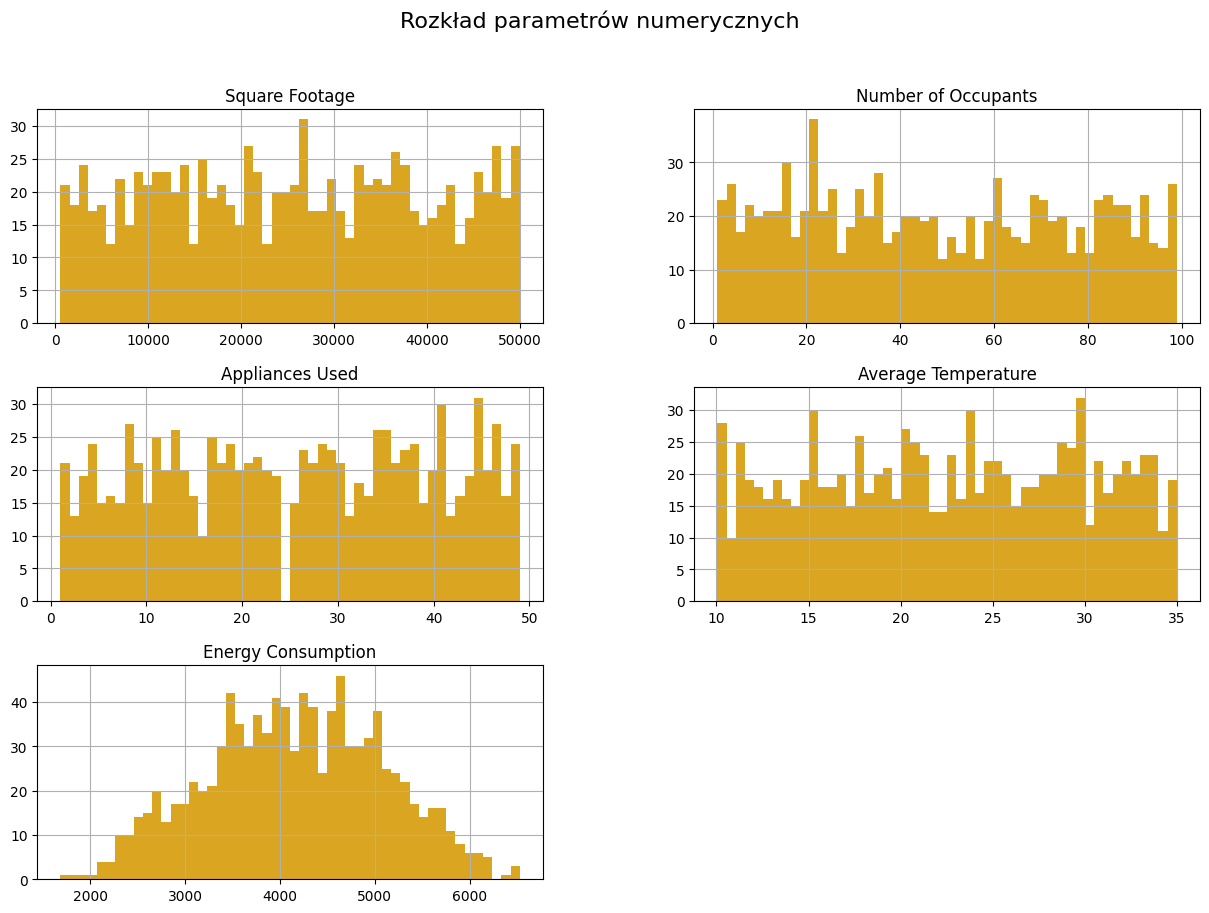

In [ ]:
%matplotlib inline
energy.hist(bins=50, figsize=(15,10), color='goldenrod')
plt.suptitle("Rozkład parametrów numerycznych", fontsize=16)
plt.show()

## 2.3 Mapa korelacji (heatmap)


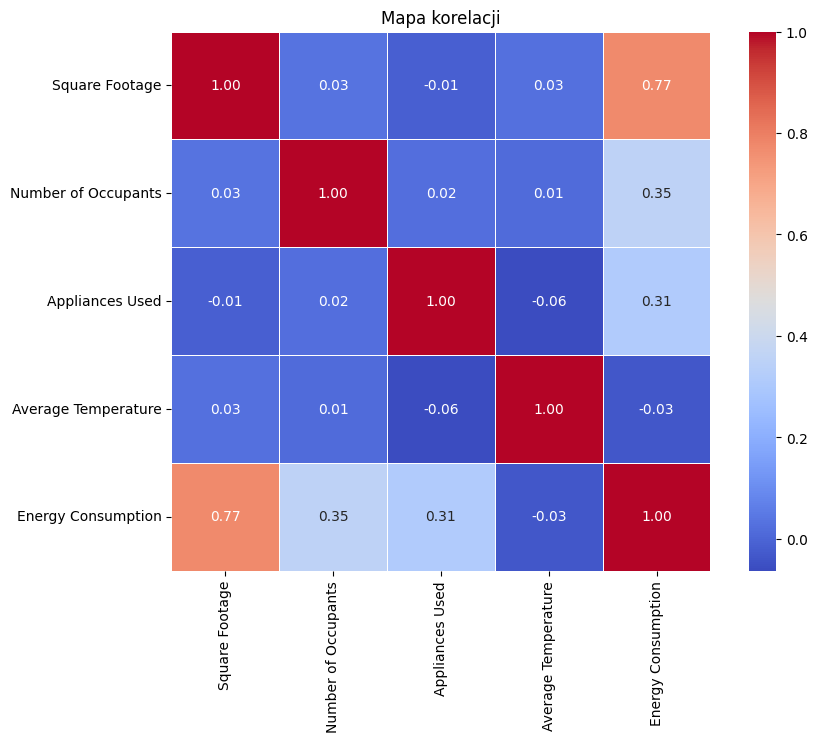

Korelacja cech z Energy Consumption:
Energy Consumption     1.000000
Square Footage         0.774873
Number of Occupants    0.354485
Appliances Used        0.312792
Average Temperature   -0.034487


In [ ]:
plt.figure(figsize=(10, 7))
korelacja = energy.select_dtypes(include=np.number).corr()
sns.heatmap(korelacja, annot=True, fmt='0.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Mapa korelacji')
plt.show()

print("Korelacja cech z Energy Consumption:")
print(korelacja['Energy Consumption'].sort_values(ascending=False).to_string())

Na podstawie heatmapy oraz zestawienia wyników pod nią można zauważyć, że w procesie zużywania energii bardzo dużą rolę gra `Square Footage`. Jednocześnie kolumna `Average Temperature` osiąga ujemny wynik, co mówi nam o tym, że wysokość przeciętnej temperatury danego budynku nie posiada związku z zużyciem energii.

# **3. Przygotowanie danych do utworzenia modeli.**

## 3.1 Data cleaning

Pomimo tego, że funkcja `describe` nie wskazała braków w danych z pliku, warto zająć się potencjalnymi duplikatami i outlierami.

In [ ]:
print("Brakujące wartości per kolumna:")
print(energy.isnull().sum())

duplikat = energy.duplicated().sum()
print(f"\nLiczba znalezionych duplikatów: {duplikat}")
if duplikat > 0:
    energy = energy.drop_duplicates()
    print("Duplikaty zostały usunięte.")

Brakujące wartości per kolumna:
Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64

Liczba znalezionych duplikatów: 0


In [ ]:
Q1 = energy['Energy Consumption'].quantile(0.25)
Q3 = energy['Energy Consumption'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

energy_cleaned = energy[(energy['Energy Consumption'] >= lower_bound) & (energy['Energy Consumption'] <= upper_bound)]

print(f"Liczba wierszy przed czyszczeniem: {len(energy)}")
print(f"Liczba wierszy po czyszczeniu: {len(energy_cleaned)}")

energy = energy_cleaned

Liczba wierszy przed czyszczeniem: 1000
Liczba wierszy po czyszczeniu: 1000


Do wykrycia i usunięcia potencjalnych outlierów użyłam metody IQR, która szuka środkowych wartości oraz odcina skrajności (anomalie). Proces czyszczenia danych przeszedł pomyślnie, więc można zająć się przygotowaniem danych do trenowania.

## 3.2 Podział danych i przygotowanie (train_test_split + Pipeline)

In [ ]:
X = energy.drop("Energy Consumption", axis=1) # cechy
y = energy["Energy Consumption"].copy() # cel

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Tworzymy nowa ramę z wszystkimi kolumnami oprócz `Energy Consumption`, aby samodzielnie zbudować modele predykcyjne.
Następnie za pomocą `train_test_split` dzielimy dane na zbiór treningowy oraz testowy.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer # uzupełnianie wartości
from sklearn.preprocessing import StandardScaler, OneHotEncoder # skalowanie cech numerycznych, kodowanie cech kategorycznych

c_attribs = ['Building Type', 'Day of Week']
n_attribs = X_train.select_dtypes(include=[np.number]).columns.tolist()

n_pipeline = Pipeline([ # potok numeryczny
    ('imputer', SimpleImputer(strategy='median')), # uzupełnienie medianą
    ('scaler', StandardScaler())]) # średnia 0, odchylenie standardowe 1

c_pipeline = Pipeline([ # potok kategoryczny
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

pipeline = ColumnTransformer([ # potok złączony
    ('num', n_pipeline, n_attribs),
    ('cat', c_pipeline, c_attribs)])

X_train_final = pipeline.fit_transform(X_train)
X_test_final = pipeline.transform(X_test)

print("Kształt macierzy treningowej:", X_train_final.shape)

Kształt macierzy treningowej: (800, 9)


Za pomocą `Pipeline` tworzymy potok. Pozwoli to przygotować model do stabilnego działania.

# **4. Budowanie modeli oraz porównanie ich działania**

## 4.1 Linear Regression

To nasz model bazowy, który pozwoli sprawdzić zależność liniową.

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_final, y_train)

y_pred_lin = lin_reg.predict(X_test_final)

rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
print(f"RMSE: {rmse_lin:.4f}")

RMSE: 0.0137


## 4.2 Random Forest (zwykły)

In [ ]:
rf_base = RandomForestRegressor(random_state=42)
rf_base.fit(X_train_final, y_train)

y_pred_rf_base = rf_base.predict(X_test_final)
rmse_rf_base = np.sqrt(mean_squared_error(y_test, y_pred_rf_base))

print(f"RMSE: {rmse_rf_base:.4f}")

RMSE: 124.7215


## 4.2 Random Forest + Grid Search

In [ ]:
rf_reg = RandomForestRegressor(random_state=42)

param_grid = [
    {'n_estimators': [10, 50, 150], # liczba drzew w lesie
     'max_depth': [10, 20, None], # maksymalna głębokość
     'min_samples_split': [2, 5, 10]}] # minimalna liczba próbek do podziału


grid_search = GridSearchCV(rf_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error', # metryka ocen
                           return_train_score=True)

grid_search.fit(X_train_final, y_train)

print("Najlepsze parametry:", grid_search.best_params_)

best_rf_model = grid_search.best_estimator_
y_pred_rf = best_rf_model.predict(X_test_final)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"RMSE: {rmse_rf:.4f}")

Najlepsze parametry: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 150}
RMSE: 123.5210


Po uwzględnieniu `GridSearchCV` w kodzie z modelem Random Forest, wskaźnik RMSE minimalnie się zmniejszył. Oznacza to, że `Grid Search` znalazł lepiej dopasowaną (minimalnie, ale lepszą) do danych kombinację parametrów

## 4.3 Porównanie modeli

In [ ]:
wyniki = pd.DataFrame({
    'Model': ['Regresja Liniowa', 'Las Losowy (bazowy)', 'Las Losowy (Grid Search)'],
    'RMSE': [rmse_lin, rmse_rf_base, rmse_rf]})

print("\n=== PODSUMOWANIE I PORÓWNANIE MODELI ===")
print(wyniki.to_string(index=False))

lepszy_model = wyniki.loc[wyniki['RMSE'].idxmin()]['Model']
print(f"\nLepszy model: '{lepszy_model}'.")


=== PODSUMOWANIE I PORÓWNANIE MODELI ===
                   Model       RMSE
        Regresja Liniowa   0.013731
     Las Losowy (bazowy) 124.721541
Las Losowy (Grid Search) 123.521041

Lepszy model: 'Regresja Liniowa'.


## Podsumowanie, wnioski końcowe.


*   Mimo udanej optymalizacji Lasu Losowego, model **Regresji Liniowej** wciąż pozostaje najlepszym modelem, ponieważ uzyskał najniższą wartość RMSE = 0.0137.
*   `GridSearchCV` pozwoliło na zoptymalizowanie modelu Random Forest i minimalne zmniejszenie wskaźnika RMSE.

